In [38]:
import sys
import os

# Forzamos a que Python use UTF-8 para leer archivos si estamos en Windows
os.environ["PYTHONIOENCODING"] = "utf-8"

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from preprocesado import preprocesado, seleccion_caracteristicas_check
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier   # Asegurarse de tener xgboost instalado: pip install xgboost
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
# Cargamos datos
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

ids_test_final = test['ID_Cliente'].copy()
# Preprocesamos datos
train_tree_pre, train_linear_pre, test_tree_pre, test_linear_pre = preprocesado(train, test)

X_train_tree = train_tree_pre.drop(columns=['Target_Risco'])
y_train_tree = train_tree_pre['Target_Risco']   
X_train_linear = train_linear_pre.drop(columns=['Target_Risco'])
y_train_linear = train_linear_pre['Target_Risco']

In [40]:
# Preprocesado
X_train_tree.head()


,num__Idade,num__Lonxitude_Nome,num__Num_Fillos,num__Anos_Emprego,num__Ingresos_Anuais,num__Tempo_Web_Minutos,num__Distancia_Oficina_Km,num__Debeda_Total,num__Numero_Tarxetas,num__Ratio_Deuda_Patrimonio,...,num__Saldo_Medio_3M,num__Variacion_Saldo_6M,num__Fondo_Emerxencia_Meses,num__Indice_Estres_Financeiro,cat__Profesion,cat__Tipo_Dispositivo,cat__Dia_Solicitude,target__Codigo_Postal,bin__Subscricion_Email,bin__Historial_Impagos
0,27.0,17.0,2.0,2.1,7660.67,45.000000,17.3,2409.78,3.0,0.062099,...,489.85,-0.091,8.11,0.234,1.0,0.0,5.0,27004.0,0.0,0.0
1,30.0,12.0,1.0,2.2,9629.39,30.500000,0.5,184.08,2.0,0.002440,...,231.86,-0.183,24.00,0.128,0.0,3.0,0.0,27001.0,0.0,0.0
2,42.0,29.0,1.0,0.0,3332.75,22.975003,24.2,84.89,3.0,0.001959,...,221.12,-0.047,24.00,0.163,2.0,3.0,3.0,15008.0,0.0,1.0
3,33.0,16.0,0.0,0.0,6993.01,21.500000,40.1,380.62,3.0,0.008411,...,392.57,0.192,24.00,0.000,2.0,0.0,4.0,27002.0,1.0,0.0
4,56.0,18.0,2.0,13.7,26668.10,26.900000,20.9,3455.41,0.0,0.038357,...,3160.21,-0.094,24.00,0.027,1.0,4.0,5.0,15007.0,0.0,0.0


In [41]:
# Modelo 1: Random Forest
def m1_bagging_RF(X_train, y_train, X_test):
    modelo = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1 # Para que use todos tus núcleos y sea más rápido
    )
    
    # Entrenamos con todo el conjunto de entrenamiento disponible
    modelo.fit(X_train, y_train)
    
    # Predecimos sobre el test de la competición
    preds = modelo.predict(X_test)
    
    return "random_forest", preds

In [42]:
# Modelo 2: XGBoost
def m2_boosting_XGB(X_train, y_train, X_test):
    modelo = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=4,
        random_state=42
    )
    
    # Nota: En Kaggle, al predecir el test final, no solemos usar 'eval_set' 
    # porque no tenemos el y_test. Entrenamos con todo el bloque de train.
    modelo.fit(X_train, y_train)
    
    preds = modelo.predict(X_test)
    
    return "xgb", preds

In [43]:
# 1. Obtenemos las predicciones
nombre_rf, preds_rf = m1_bagging_RF(X_train_tree, y_train_tree, test_tree_pre)
nombre_xgb, preds_xgb = m2_boosting_XGB(X_train_tree, y_train_tree, test_tree_pre)

# 2. Creamos el archivo para Kaggle
submission_rf = pd.DataFrame({
    "ID_Cliente": ids_test_final, 
    "Target_Risco": preds_xgb
})
submission_rf.to_csv("results/submission_rf-v2.csv", index=False)
submission_xgb = pd.DataFrame({
    "ID_Cliente": ids_test_final, 
    "Target_Risco": preds_xgb
})
submission_xgb.to_csv("results/submission_xgb-v2.csv", index=False)

print("Archivos de sumisiones creado con éxito.")

Archivos de sumisiones creado con éxito.


In [24]:
# Ver recuento de nulos por columna
nulos_por_columna = X_train_linear.isnull().sum()
print(nulos_por_columna[nulos_por_columna > 0])

# Ver qué filas tienen nulos (opcional)
filas_con_nulos = X_train_linear[X_train_linear.isnull().any(axis=1)]
print(f"\nTotal de filas con NaNs: {len(filas_con_nulos)}")

Series([], dtype: int64)

Total de filas con NaNs: 0


In [35]:
# Selección características (linear)
X_train_linearv2 = X_train_linear.drop(columns=['num__Patrimonio_Total', 'num__Debeda_Total'])
scores_kbest = seleccion_caracteristicas_check(X_train_linear, y_train_linear)
scores_kbest
# Mirar SelectFromModel de Scikit-Learn.

,Característica,Puntuación
44,bin__Historial_Impagos,5114.593330
11,num__Ratio_Deuda_Ingresos,2525.426732
18,num__Ratio_Cota_Ingresos,2405.046976
15,num__Consultas_Risco_6M,2360.660646
23,num__Fondo_Emerxencia_Meses,1477.635794
24,num__Indice_Estres_Financeiro,1116.018680
10,num__Ratio_Deuda_Patrimonio,651.336085
8,num__Debeda_Total,537.733264
19,num__Prestamos_Activos,501.324694
17,num__Cota_Mensual_Prestamos,250.347379


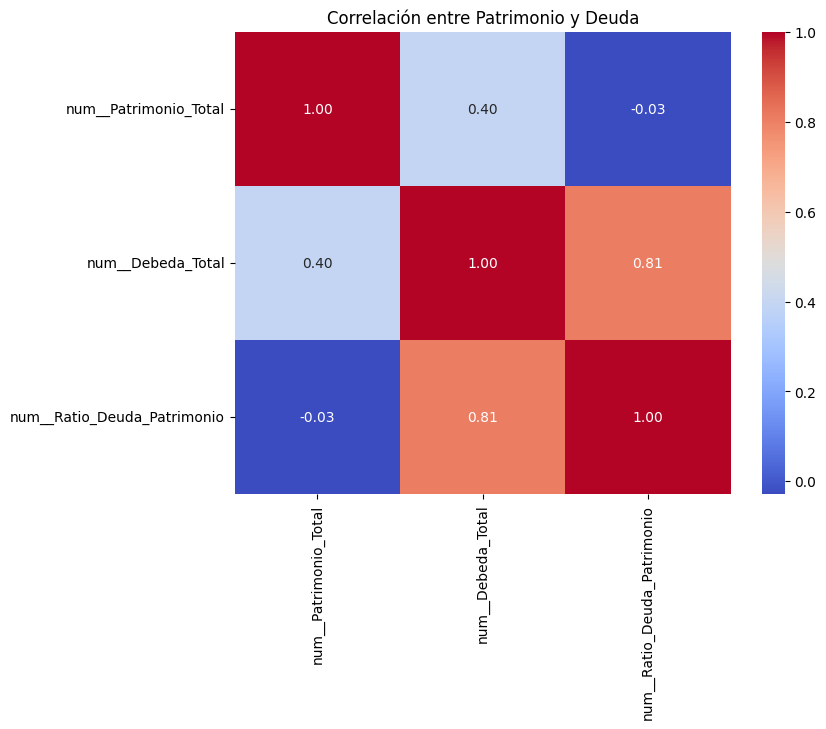

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Elegimos las variables sospechosas
cols_interes = ['num__Patrimonio_Total', 'num__Debeda_Total', 'num__Ratio_Deuda_Patrimonio']
matriz_corr = X_train_linear[cols_interes].corr()

# 2. Dibujamos el Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación entre Patrimonio y Deuda")
plt.show()